In [16]:
# download data from
# https://1drv.ms/f/c/977904c31b5ebf00/IgDZC6JRz-qiQbu0aep4c5BWAUjSlQewykyX9ke1PGZjBkY?e=hLLhFU

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
# imagefolder
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from tqdm import tqdm
import os
import shutil

In [18]:
# the data lives in two folders in the data\raw folder, one for each class. The folder names are the class labels.
# this script will split the data into training and test sets, and maintain the same folder structure within the train and test folders.
# automatic detection of classes should be done by ImageFolder, so we don't need to hardcode the class names.
# ensure that the raw data is never modified.

def split_data(data_dir, train_dir, test_dir, test_size):
    import os
    import shutil
    from sklearn.model_selection import train_test_split

    # Start fresh each run.
    if os.path.exists(train_dir):
        shutil.rmtree(train_dir)
    if os.path.exists(test_dir):
        shutil.rmtree(test_dir)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Read from raw class folders and copy files into train/test.
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        if not images:
            continue
        # print(images)
        
        # train_images, test_images = train_test_split(
        #     images, test_size=test_size, random_state=42
        # )
        # first 80% of the images go to train, last 20% go to test, alphabetically sorted
        images.sort()
        split_index = int(len(images) * (1 - test_size))
        train_images = images[:split_index]
        test_images = images[split_index:]

        train_class_dir = os.path.join(train_dir, class_name)
        test_class_dir = os.path.join(test_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        for img in train_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(train_class_dir, img))
        for img in test_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(test_class_dir, img))


split_data('data/raw', 'data/train', 'data/test', test_size=0.2)

In [19]:
# count images in each folder and print the counts
d = {}

for root, dirs, files in os.walk("data"):
    count = sum(file.lower().endswith(".png") for file in files)

    if count > 0:
        d[root] = count

print(d)

{'data\\raw\\ansh': 581, 'data\\raw\\varsha': 466, 'data\\test\\ansh': 117, 'data\\test\\varsha': 94, 'data\\train\\ansh': 464, 'data\\train\\varsha': 372}


In [20]:
from model_definition import transform

train_dataset = ImageFolder(root=r'data\train', transform=transform)
test_dataset = ImageFolder(root=r'data\test', transform=transform)


In [21]:
# examine the dataset
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# shape of the first image
print(f"Shape of the first image: {train_dataset[0][0].shape}")
print(f"Label of the first image: {train_dataset[0][1]}")
# test
print(f"Shape of the first test image: {test_dataset[0][0].shape}")
print(f"Label of the first test image: {test_dataset[0][1]}")

# class names
print(f"Class names: {train_dataset.classes}")

Number of classes: 2
Number of training samples: 836
Number of test samples: 211
Shape of the first image: torch.Size([3, 128, 128])
Label of the first image: 0


Shape of the first test image: torch.Size([3, 128, 128])
Label of the first test image: 0
Class names: ['ansh', 'varsha']


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# move dataloaders to GPU if available
train_loader = DataLoader(train_dataset, batch_size=32*4, shuffle=True, pin_memory=True if torch.cuda.is_available() else False)
test_loader = DataLoader(test_dataset, batch_size=32*4, shuffle=False, pin_memory=True if torch.cuda.is_available() else False)


In [23]:
from model_definition import model
# model = ImgTxtClassifier()
# model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()  
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=3e-3)  # L2 regularization
train_losses = []
test_losses = []

In [24]:

epochs = 20
best_test_loss = float('inf')
patience = 5
for epoch in tqdm(range(epochs), desc="Training Progress (epochs)"):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        # labels = labels.float().unsqueeze(1)  # convert to float and add dimension for BCEWithLogitsLoss
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # scheduler.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))
    # get last learning rate from scheduler
    # print(scheduler.get_last_lr())
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # labels = labels.float().unsqueeze(1)  # convert to float and add dimension for BCEWithLogitsLoss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

    test_losses.append(test_loss / len(test_loader))
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), "best_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    
    print(
        f"Epoch {epoch+1:2d} | "
        # f"LR={scheduler.get_last_lr()[0]:.6f} | "
        f"Train={train_losses[-1]:.4f} | "
        f"Val={test_losses[-1]:.4f}"
    )

model.load_state_dict(torch.load("best_model.pth"))

Training Progress (epochs):   0%|          | 0/20 [00:00<?, ?it/s]

Training Progress (epochs):   5%|▌         | 1/20 [00:59<18:59, 59.99s/it]

Epoch  1 | Train=0.3052 | Val=0.3056


Training Progress (epochs):  10%|█         | 2/20 [01:23<11:34, 38.59s/it]

Epoch  2 | Train=0.2059 | Val=0.2473


...

Training Progress (epochs):  35%|███▌      | 7/20 [03:15<05:11, 23.95s/it]

Epoch  7 | Train=0.0720 | Val=0.2931


Training Progress (epochs):  35%|███▌      | 7/20 [03:38<06:46, 31.25s/it]

Early stopping at epoch 8


<All keys matched successfully>

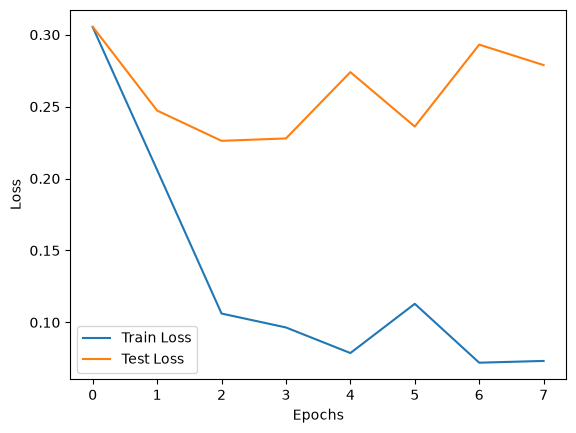

In [25]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [26]:
# Training accuracy, 2 classes, use argmax to get predicted class

correct = 0
total = 0
misclassified_images = []
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)  # get the index of the max log-probability
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # list down the predicted and actual labels for each image in the batch
        for i in range(len(labels)):
            # print(f"Predicted: {predicted[i].item()}, Actual: {labels[i].item()}")
            if predicted[i].item() != labels[i].item():
                #print(f"Misclassified image index in batch: {i}")
                # name of the image in the dataset
                #print(f"Image path: {test_dataset.samples[i][0]}")
                # raw logits of misclassified image
                #print(f"Raw logits: {outputs[i].data}")
                misclassified_images.append((images[i], predicted[i].item(), labels[i].item(), outputs[i].data))

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9677


In [27]:
# Validation accuracy, 2 classes, use argmax to get predicted class

correct = 0
total = 0
misclassified_images = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)  # get the index of the max log-probability
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # list down the predicted and actual labels for each image in the batch
        for i in range(len(labels)):
            # print(f"Predicted: {predicted[i].item()}, Actual: {labels[i].item()}")
            if predicted[i].item() != labels[i].item():
                #print(f"Misclassified image index in batch: {i}")
                # name of the image in the dataset
                #print(f"Image path: {test_dataset.samples[i][0]}")
                # raw logits of misclassified image
                #print(f"Raw logits: {outputs[i].data}")
                misclassified_images.append((images[i], predicted[i].item(), labels[i].item(), outputs[i].data))

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9336


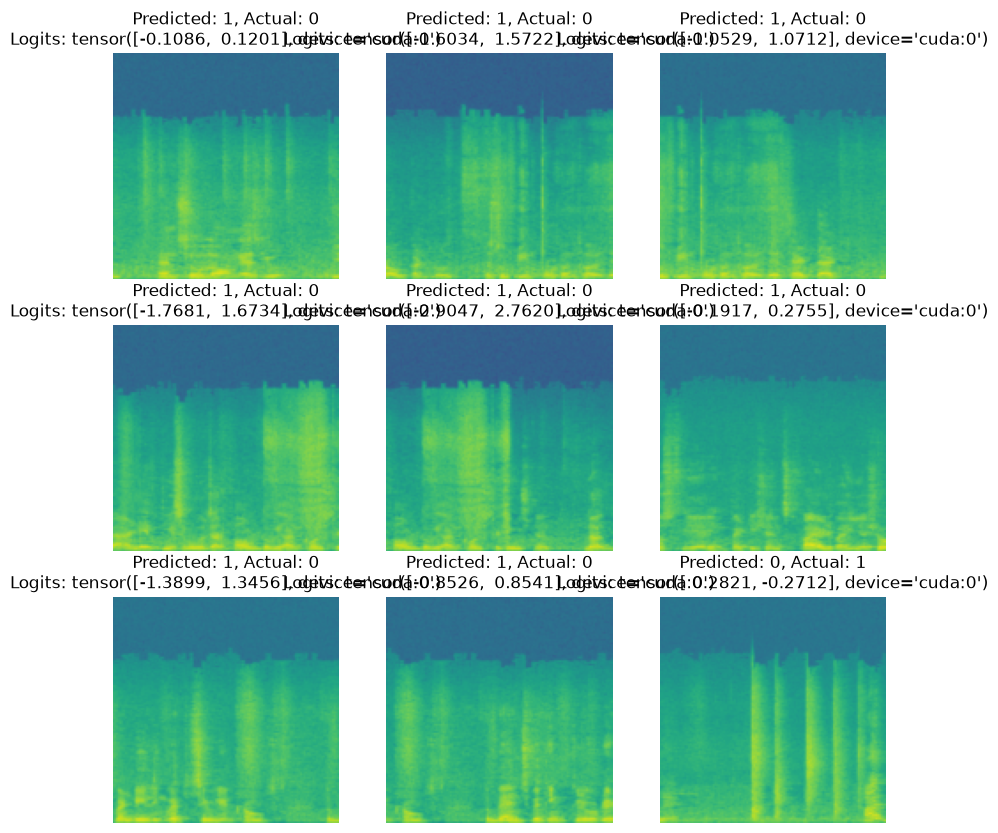

Class names: ['ansh', 'varsha']


In [28]:
# display the misclassified images with their predicted and actual labels and logits
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 10))
misclassified_images = misclassified_images[:9]  # display only the first 9 misclassified images
for i, (image, predicted_label, actual_label, logits) in enumerate(misclassified_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.cpu().permute(1, 2, 0))  # convert from (C, H, W) to (H, W, C)
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}\nLogits: {logits}")
    plt.axis('off')
plt.show()

# print actual label names mapped to 0 and 1
print(f"Class names: {train_dataset.classes}")

In [29]:
# save the model
torch.save(model.state_dict(), "ansh_varsha_classifier.pth")

In [30]:
# # inference

# # step 1 is to load the model and the state dict
# model = ImgTxtClassifier()
# model.load_state_dict(torch.load("img_txt_classifier.pth"))

# # step 2 is to set the model to evaluation mode
# model.eval()

# # path of the image to be classified
# from PIL import Image
# path = r"C:\Users\101119\Pictures\screenshots\Screenshot 2023-08-08 115445.png"

# # step 3 is to load the image and apply the same transformations as during training
# image = Image.open(path).convert("RGB")
# transformed_image = transform(image).unsqueeze(0)  # add batch dimension

# # step 4 is to pass the image through the model and get the predicted class
# with torch.no_grad():
#     output = model(transformed_image)
#     _, predicted_class = torch.max(output.data, 1)
#     print("Predicted class:", predicted_class.item())
#     print("Predicted class name:", train_dataset.classes[predicted_class.item()])


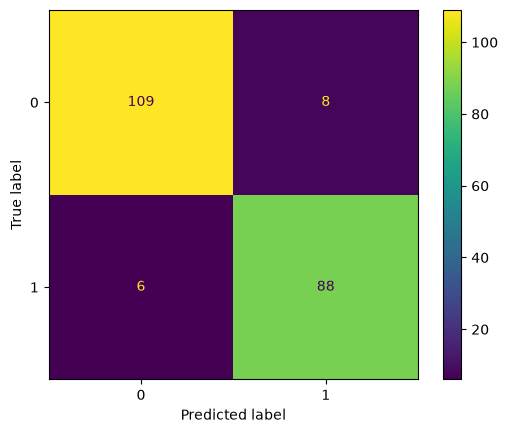

In [31]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# calculate y_true and y_pred for the test set
y_true = []
y_pred = []

for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted.cpu().numpy())
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [32]:
paths = [path for path, label in test_dataset.samples]

for path, true, pred in zip(paths, y_true, y_pred):
    if true != pred:
        print(path, "True:", true, "Pred:", pred)

data\test\ansh\ansh_7_040.png True: 0 Pred: 1
data\test\ansh\ansh_8_010.png True: 0 Pred: 1
data\test\ansh\ansh_8_011.png True: 0 Pred: 1
data\test\ansh\ansh_8_014.png True: 0 Pred: 1
data\test\ansh\ansh_8_015.png True: 0 Pred: 1
data\test\ansh\ansh_8_031.png True: 0 Pred: 1
data\test\ansh\ansh_8_046.png True: 0 Pred: 1
data\test\ansh\ansh_8_047.png True: 0 Pred: 1
data\test\varsha\varsha_7_035.png True: 1 Pred: 0
data\test\varsha\varsha_7_036.png True: 1 Pred: 0
data\test\varsha\varsha_8_009.png True: 1 Pred: 0
data\test\varsha\varsha_8_037.png True: 1 Pred: 0
data\test\varsha\varsha_8_044.png True: 1 Pred: 0
data\test\varsha\varsha_8_047.png True: 1 Pred: 0
